# COMP1117: Computer programming - Tutorial 9

Welcome to Tutorial 9!

## Announcements:
- Tutorial Exercise 9 released. It is due 23:59 28 Nov, 2025
- Assignment 4 released. Due 1st Dec, 23:59
- [Student Feedback on Teaching and Learning](http://sftl.hku.hk/)

## 1. Lecture Recap

In the last lecture, we have covered:
- File I/O in Python
- Error handling in Python

### 1.1 File I/O
I/O = Input / Output

    Input → reading data from a file

    Output → writing data to a file

what you have learned:
- `open()`, `close()` function
- `read()`, `write()` methods

Some flags in `open()` function:
- `'r'` : read (default)
- `'w'` : write (overwrite if file exists)
- `'a'` : append (add data to the end of file)

The following is not covered in the lecture, but you may find them useful:
- `'rb'` : read in binary mode (some other data format, e.g., image)
- `'wb'` : write in binary mode (some other data format, e.g., image)

Why `close` matters?
- Free up system resources
- Ensure data is written to file (especially for write/append mode)

Otherwise there could be file descriptor leak or data loss!

\[Demo\]

In [81]:
import os

pwd = os.getcwd()
print(f"Current working directory: {pwd}")

data_path = os.path.join(pwd, 'data/comp1117.txt') # I use relative path here
# e:\code\COMP1117\Tutorial9 + comp1117.txt

fin = open(data_path, 'r') # this creates a file in stream, file object

# print(type(fin))  # <class '_io.TextIOWrapper'>

for i in fin:
    print(i.strip())
fin.close()

fout = open(data_path, 'a')
fout.write("\nNew line added.")
fout.close()


Current working directory: e:\code\COMP1117\Tutorial9
Syntax, identifiers, control statements, functions, recursions, and strings
Programming style, program documentation
Lists, dictionaries, tuples and files


New line added.


Some other important usages (very likely will not be tested):
- readline() : read one line at a time
- readlines() : read all lines into a list

In [58]:
fin = open(data_path, 'r')
lines = fin.readlines()
print(lines)
fin.close()


['Syntax, identifiers, control statements, functions, recursions, and strings\n', 'Programming style, program documentation\n', 'Lists, dictionaries, tuples and files\n', '\n']


An important feature of Python File I/O: **Context Manager**

Remember keywords: `with` ... `as` ...?

In [60]:
import keyword
print(keyword.kwlist)

['False', 'None', 'True', 'and', 'as', 'assert', 'async', 'await', 'break', 'class', 'continue', 'def', 'del', 'elif', 'else', 'except', 'finally', 'for', 'from', 'global', 'if', 'import', 'in', 'is', 'lambda', 'nonlocal', 'not', 'or', 'pass', 'raise', 'return', 'try', 'while', 'with', 'yield']


In [ ]:
with open(data_path, 'r') as f: # f = open(data_path, 'r')
    for line in f:
        print(line.strip())

Syntax, identifiers, control statements, functions, recursions, and strings
Programming style, program documentation
Lists, dictionaries, tuples and files


New line added.


Advantages:

- Automatically closes the file even if an error occurs
- Cleaner and safe  
- Standard practice in industry code

A context manager created by `with` statement calls `__enter__` method at the beginning and `__exit__` method at the end. (some built-in magic methods)

A little more about File I/O:

File operations require communication between:

1. Your Python program
2. Operating System (OS) → manages files
3. Hardware → actual disk (SSD/HDD)

Each read/write is a system call, which is much slower than CPU operations.

CPU: billions of ops/sec

Disk I/O: thousands to millions ops/sec

**I/O is often the bottleneck in real programs!**

You will learn more about File I/O in later courses. (COMP2120 Computer Architecture and Organization and COMP3230 Operating Systems)

### 1.2 Error Handling
- Prevent crashing
- Provide meaningful messages
- Allow fallback logic

The basic syntax:

```python
try:
    # code that may raise an exception
except SomeException as e:
    # code to handle the exception
else:
    # code to run if no exception occurs
finally:
    # code that always runs, regardless of exceptions
```

In [63]:
x = int(input("Enter integer: "))
y = 10 / x

ZeroDivisionError: division by zero

In [ ]:
try:
    x = int(input("Enter integer: "))
    y = 10 / x
except ValueError:
    print("Invalid integer!")
except ZeroDivisionError:
    print("Cannot divide by zero!")

Cannot divide by zero!
program goes on


How to Read a Python Error Message?
\[Demo\]

Common Build-in Exceptions/Errors:
| Exception           | When it happens                       |
| ------------------- | ------------------------------------- |
| `ValueError`        | Wrong type/format (e.g., `int("hi")`) |
| `TypeError`         | Wrong type used in operation          |
| `IndexError`        | List index out of range               |
| `KeyError`          | Dictionary key not found              |
| `FileNotFoundError` | File path invalid                     |
| `ZeroDivisionError` | Division by zero                      |
| `AttributeError`    | Access undefined attribute            |
| `ModuleNotFoundError`| Cannot import module                 |

You can find more here: https://docs.python.org/3/library/exceptions.html

A bonus tip: You can define your own Exception classes by inheriting from the built-in `Exception` class. (advanced topic, not covered in this course)

In [74]:
string = "2025/11/18"

list_data = string.split("/")
print(list_data)

joint = "-".join(list_data)
print(joint)

['2025', '11', '18']
2025-11-18


## 2. Tutorial Slides & Exercises

About string manipulation and some methods.

### Exercise 9.1 Last word of input (Optional)
Write a program that reads in a string s and then prints the last word in s.

Note:
The input string can contain letters, spaces, and period symbols. The last word should only containletters. You may need to remove the unnecessary symbol (e.g., period symbol) in the word.

In [75]:
s = input()
last = s.split()[-1]
last.strip(".")

'COMP1117'

### 9.2 Max number in input (Optional)
Write a program to read a line of digit-strings separated by comma and print the max number in them.

In [77]:
max_num = max(map(int, input().split(",")))
print(max_num)

10


### Exercise 9.3 Check credit card number (Submission Required!)
Write a program to read a line of credit card number which each 4-digit parts are separated by space and use the ‘Luhn Algorithm’ to check if the card number is valid.
Luhn Algorithm is descripted as follow. You need to use the Luhn Algorithm to check if the calculated check digit is the same as the one from the input.

1. Remove the check digit (last digit) from the number

2. Calculate the check digit

    2.1. Take the number and start from the rightmost digit and move to left, double the value of every second digit (including the rightmost digit).

    2.2. Calculate the sum of the digits of the result for each position.

    2.3 Sum up the resulting values from all positions as **s**.

    2.4 The calculated check digit is equal to $10 - (s \mod 10)$

3. Compare your result with the check digit from the input. The card number is valid when these two numbers are the same.

Reference: https://en.wikipedia.org/wiki/Luhn_algorithm

In [ ]:
from sum_digit_utils import sum_digit

s = input().replace(" ","")

checker = s[-1]

rest = s[:-1]

rest = rest[::-1] # 7654321

luhn_sum = 0

for i, obj in enumerate(rest): # enumerate(Iterable)
    if i % 2 == 0:
        doubled_digit = int(obj) * 2
        luhn_sum += sum_digit(doubled_digit)
    else: 
        luhn_sum += int(obj)

new_checker = 10 - (luhn_sum % 10)

print(new_checker == checker)

False


## Some Bonus: working with more file types in Python
So far we’ve talked about reading and writing “regular” text files using open() and understanding exceptions when files go wrong. But in real projects, you almost never deal with plain text only. Instead, you’ll frequently work with structured data formats like CSV and JSON—and sometimes even binary files like images.


### 1. CSV Files: Built-in `csv` vs Pandas

CSV (usually comma-separated values) files store table-like data as plain text.
Python provides the `csv` module for low-level control, while **Pandas** offers a fast and convenientinterface designed for data analysis.

---

#### 1.1 CSV with Built-in `csv` Module (Low-Level, Conceptual)

### **Reading CSV**

In [ ]:
import csv

file_path = os.path.join(os.getcwd(), "data/username.csv")

with open(file_path, "r") as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)

When to use it:

* when learning how file streams work
* when implementing your own parser
* when avoiding external dependencies

But **in real work, data scientists almost always use Pandas**.


In [ ]:
! pip install pandas


#### 1.2 CSV with Pandas (Recommended for Data Science)

[Pandas](https://pandas.pydata.org/) is optimized, powerful, and extremely convenient.

In [ ]:
import pandas as pd

df = pd.read_csv(file_path)
print(df.head())   # first 5 rows

In [ ]:
Usernames = df['Username']
print(Usernames)

In [ ]:
filtered_users = df[df[' Identifier'] >= 5000]
print(filtered_users)

In [ ]:
print(df.describe())

All the tables are stored as `DataFrame` objects in Pandas, which is a powerful sturcture for handling tabular data. You will learn more about tabular data in later courses (e.g., COMP2501 Data Science and Engineering).

Why Pandas?

* handles missing values automatically
* supports complex operations **in one line**
* integrates well with `NumPy` / `SciPy` / ML libraries
* **industry standard** for data analysis
---

#### 2. Working with JSON in Python

JSON (JavaScript Object Notation) is widely used for configuration files, APIs, and web data. It looks quite similar to Python dictionaries and lists, making it easy to work with in Python.

In [ ]:
import json

with open("data/config.json", "r") as f:
    data = json.load(f)

print(data)

In [ ]:
settings = {"name": "Alice", "age": 20}

with open("data/settings.json", "w") as f:
    json.dump(settings, f, indent=4)


JSON maps directly to:

| JSON       | Python     |
| ---------- | ---------- |
| object     | dict       |
| array      | list       |
| true/false | True/False |
| null       | None       |

---

#### 3. Working with Images in Python

Python can handle images through the Pillow (PIL) library.

In [ ]:
! pip install pillow

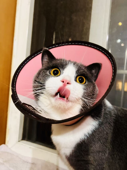

In [80]:
from PIL import Image

img = Image.open("asset/cat.jpg")

# resize image
w, h = img.size
ratio = 0.10

img.resize((int(w * ratio), int(h * ratio)))

In the era of AI, you just need to know there exist such libraries or tools in data science. You do not have to master all these libraries or memorize all Methods. Talk with Large Language Models (LLMs) like ChatGPT to help you with learning!